# Threshold Calibration

Derive quality-rule thresholds from the actual distribution of metric values
across all 68 dictionaries, rather than using arbitrary hand-picked values.

## Method

For each metric that drives a quality rule, two derivation paths:

1. **Bimodal distributions** — detect a natural valley between two peaks
   using a simple local-minimum search on the histogram. The valley is
   the principled threshold because it separates the two modes in the data.

2. **Unimodal distributions** — use a quantile (typically the 75th
   percentile for "high X is bad" rules, 25th percentile for "low X is bad"
   rules). This means roughly 25% of dictionaries are flagged by each rule
   — a useful discriminator that avoids flagging the whole corpus.

Every threshold is checked against the 4 reference "good" dictionaries
(#10, #35, #68, #91): if any reference dict falls on the wrong side of the
derived threshold, we widen the threshold to accommodate it. This ensures
the reference dictionaries always pass.

## Outputs

- `_threshold_justifications.csv` — one row per rule with threshold value,
  derivation method, and a justification string suitable for the thesis
- `_threshold_distributions.png` — one histogram per metric showing the
  distribution and where the threshold landed

These are consumed by `Distribution Sanity Checks v2.ipynb`.

## Rules covered

9 rules after removing the two that never fired (`billex_high_identical`,
`billex_high_duplicates`):

| Resource | Rule | Direction |
|---|---|---|
| Billex | too_few_rows | lower is worse |
| Billex | high_null_rate | higher is worse |
| Billex | high_multiword_ind | higher is worse |
| Morph | too_few_rows | lower is worse |
| Morph | low_tag_coverage | lower is worse |
| Parcor | too_few_rows | lower is worse |
| Parcor | high_null_rate | higher is worse |
| Parcor | high_placeholders | higher is worse |
| Parcor | high_short_rows | higher is worse |

## 1. Load metrics from the previous sanity check run

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SRC_METRICS = Path("../evaluation/sanity/_per_dict_metrics.csv")
DST_DIR = Path("../evaluation/calibration")
DST_DIR.mkdir(parents=True, exist_ok=True)

assert SRC_METRICS.exists(), (
    f"Metrics file not found: {SRC_METRICS}. "
    "Run the original Distribution Sanity Checks notebook first to produce it."
)

metrics = pd.read_csv(SRC_METRICS)
print(f"Loaded {len(metrics)} dictionaries with {len(metrics.columns)} columns")

Loaded 68 dictionaries with 66 columns


## 2. Define which metric drives each rule

Each threshold rule is paired with: (a) the metric column it reads, (b) whether
"high" or "low" values are bad, and (c) what fallback quantile to use if the
distribution is unimodal.

In [2]:
RULE_DEFINITIONS = {
    # Rule name                       metric column               direction  fallback_quantile
    "billex_too_few_rows":           ("billex_rows",              "low",     0.15),
    "billex_high_null_rate":         ("billex_null_rate",         "high",    0.90),
    "billex_high_multiword_ind":     ("billex_multiword_ind_rate","high",    0.75),
    "morph_too_few_rows":            ("morph_rows",               "low",     0.15),
    "morph_low_tag_coverage":        ("morph_tag_coverage",       "low",     0.25),
    "parcor_too_few_rows":           ("parcor_rows",              "low",     0.15),
    "parcor_high_null_rate":         ("parcor_null_rate",         "high",    0.90),
    "parcor_high_placeholders":      ("parcor_placeholder_rate",  "high",    0.75),
    "parcor_high_short_rows":        ("parcor_short_rate",        "high",    0.75),
}

# The 4 reference "good" dicts identified earlier — these must pass after calibration
REFERENCE_GOOD_DICTS = ["10", "35", "68", "91"]

## 3. Bimodality detection

Simple histogram-based approach: we look for two peaks separated by a
valley. A peak is a local maximum; a valley is a local minimum. A distribution
is treated as bimodal if there are ≥2 peaks with a valley between them whose
height is <60% of the shallower peak.

The threshold is set at the valley — the natural separator between the two
modes. This is the most defensible threshold because it's observationally
grounded, not picked by eye.

In [3]:
def detect_bimodality(values, n_bins=15, valley_ratio=0.6):
    """
    Returns (is_bimodal, valley_value, peaks, valleys).
    valley_value is the x-coordinate of the deepest valley between two peaks,
    or None if no valid bimodality is detected.
    """
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if len(values) < 20:
        return False, None, [], []

    counts, edges = np.histogram(values, bins=n_bins)
    mids = (edges[:-1] + edges[1:]) / 2

    peaks, valleys = [], []
    for i in range(1, len(counts) - 1):
        if counts[i] > counts[i - 1] and counts[i] > counts[i + 1]:
            peaks.append((i, counts[i], mids[i]))
        elif counts[i] < counts[i - 1] and counts[i] < counts[i + 1]:
            valleys.append((i, counts[i], mids[i]))

    if len(peaks) < 2 or len(valleys) < 1:
        return False, None, peaks, valleys

    p_first, p_last = peaks[0], peaks[-1]
    shallower_peak = min(p_first[1], p_last[1])

    # Find the valley between the first and last peaks
    best_valley = None
    for v_idx, v_count, v_mid in valleys:
        if p_first[0] < v_idx < p_last[0] and v_count < shallower_peak * valley_ratio:
            if best_valley is None or v_count < best_valley[1]:
                best_valley = (v_idx, v_count, v_mid)

    if best_valley is None:
        return False, None, peaks, valleys

    return True, best_valley[2], peaks, valleys

## 4. Derive a threshold for one rule

In [4]:
def derive_threshold(rule_name, metric_col, direction, fallback_quantile, df):
    series = df[metric_col].dropna()
    if len(series) == 0:
        return None

    # Try bimodality first
    is_bimodal, valley, peaks, valleys = detect_bimodality(series)

    # Reference dicts — for safety check
    ref_values = df[df["dict_id"].astype(str).isin(REFERENCE_GOOD_DICTS)][metric_col].dropna()

    if is_bimodal and valley is not None:
        threshold = valley
        method = "bimodal_valley"
        justification = (
            f"Distribution is bimodal with peaks near {peaks[0][2]:.3f} and "
            f"{peaks[-1][2]:.3f}. Valley at {valley:.3f} separates the two modes, "
            f"placing {(series < valley).mean() if direction == 'low' else (series > valley).mean():.0%} "
            f"of dictionaries on the unfavorable side."
        )
    else:
        threshold = series.quantile(fallback_quantile)
        method = f"quantile_{int(fallback_quantile * 100)}"
        justification = (
            f"Distribution is unimodal; threshold set at the {fallback_quantile:.0%} "
            f"percentile ({threshold:.3f}) so that roughly "
            f"{1 - fallback_quantile if direction == 'high' else fallback_quantile:.0%} "
            f"of dictionaries are flagged."
        )

    # Reference dict safety check: widen if any reference dict is flagged
    ref_violated = False
    if len(ref_values) > 0:
        if direction == "high":
            ref_violated = any(ref_values > threshold)
        else:
            ref_violated = any(ref_values < threshold)

        if ref_violated:
            # Widen threshold so all reference dicts pass
            if direction == "high":
                threshold = ref_values.max() * 1.05  # 5% buffer
            else:
                threshold = ref_values.min() * 0.95
            method += "_widened_for_references"
            justification += (
                f" WIDENED: original threshold would have flagged reference "
                f"dict(s), adjusted to {threshold:.3f} so all 4 references pass."
            )

    return {
        "rule_name": rule_name,
        "metric_column": metric_col,
        "direction": direction,
        "threshold": round(float(threshold), 4),
        "method": method,
        "justification": justification,
        "n_flagged": int(
            (series > threshold).sum() if direction == "high" else (series < threshold).sum()
        ),
        "n_total": len(series),
        "reference_dict_values": "; ".join(f"{v:.3f}" for v in ref_values.values),
    }

## 5. Run calibration for all rules

In [5]:
results = []
for rule_name, (metric_col, direction, fallback_q) in RULE_DEFINITIONS.items():
    if metric_col not in metrics.columns:
        print(f"WARNING: {metric_col} not in metrics — skipping {rule_name}")
        continue
    result = derive_threshold(rule_name, metric_col, direction, fallback_q, metrics)
    if result:
        results.append(result)

thresholds_df = pd.DataFrame(results)
thresholds_df.to_csv(DST_DIR / "_threshold_justifications.csv", index=False)

print(f"Derived {len(thresholds_df)} thresholds")
print()
display_cols = ["rule_name", "threshold", "method", "n_flagged", "n_total"]
print(thresholds_df[display_cols].to_string(index=False))

Derived 9 thresholds

                rule_name  threshold                                method  n_flagged  n_total
      billex_too_few_rows  2128.9500 bimodal_valley_widened_for_references         52       68
    billex_high_null_rate     0.0017    quantile_90_widened_for_references          6       67
billex_high_multiword_ind     0.6667                           quantile_75         15       67
       morph_too_few_rows   949.0500 bimodal_valley_widened_for_references         53       68
   morph_low_tag_coverage     0.3597                        bimodal_valley         29       60
      parcor_too_few_rows  1941.8000 bimodal_valley_widened_for_references         46       68
    parcor_high_null_rate     0.1121                           quantile_90          7       68
 parcor_high_placeholders     0.6970    quantile_75_widened_for_references          3       68
   parcor_high_short_rows     0.4785                        bimodal_valley         14       68


## 6. Justification text (for the thesis)

In [6]:
print("=" * 80)
print("THRESHOLD JUSTIFICATIONS")
print("=" * 80)
for _, row in thresholds_df.iterrows():
    print(f"\n{row['rule_name']}")
    print(f"  Metric:    {row['metric_column']} ({row['direction']} is bad)")
    print(f"  Threshold: {row['threshold']}")
    print(f"  Method:    {row['method']}")
    print(f"  Flagged:   {row['n_flagged']}/{row['n_total']} dictionaries")
    print(f"  Reference dicts:  [{row['reference_dict_values']}]")
    print(f"  Justification:    {row['justification']}")

THRESHOLD JUSTIFICATIONS

billex_too_few_rows
  Metric:    billex_rows (low is bad)
  Threshold: 2128.95
  Method:    bimodal_valley_widened_for_references
  Flagged:   52/68 dictionaries
  Reference dicts:  [3800.000; 2241.000; 6936.000; 10077.000]
  Justification:    Distribution is bimodal with peaks near 1679.500 and 5710.300. Valley at 5038.500 separates the two modes, placing 88% of dictionaries on the unfavorable side. WIDENED: original threshold would have flagged reference dict(s), adjusted to 2128.950 so all 4 references pass.

billex_high_null_rate
  Metric:    billex_null_rate (high is bad)
  Threshold: 0.0017
  Method:    quantile_90_widened_for_references
  Flagged:   6/67 dictionaries
  Reference dicts:  [0.000; 0.000; 0.002; 0.000]
  Justification:    Distribution is unimodal; threshold set at the 90% percentile (0.002) so that roughly 10% of dictionaries are flagged. WIDENED: original threshold would have flagged reference dict(s), adjusted to 0.002 so all 4 references

## 7. Visualise thresholds on the distributions

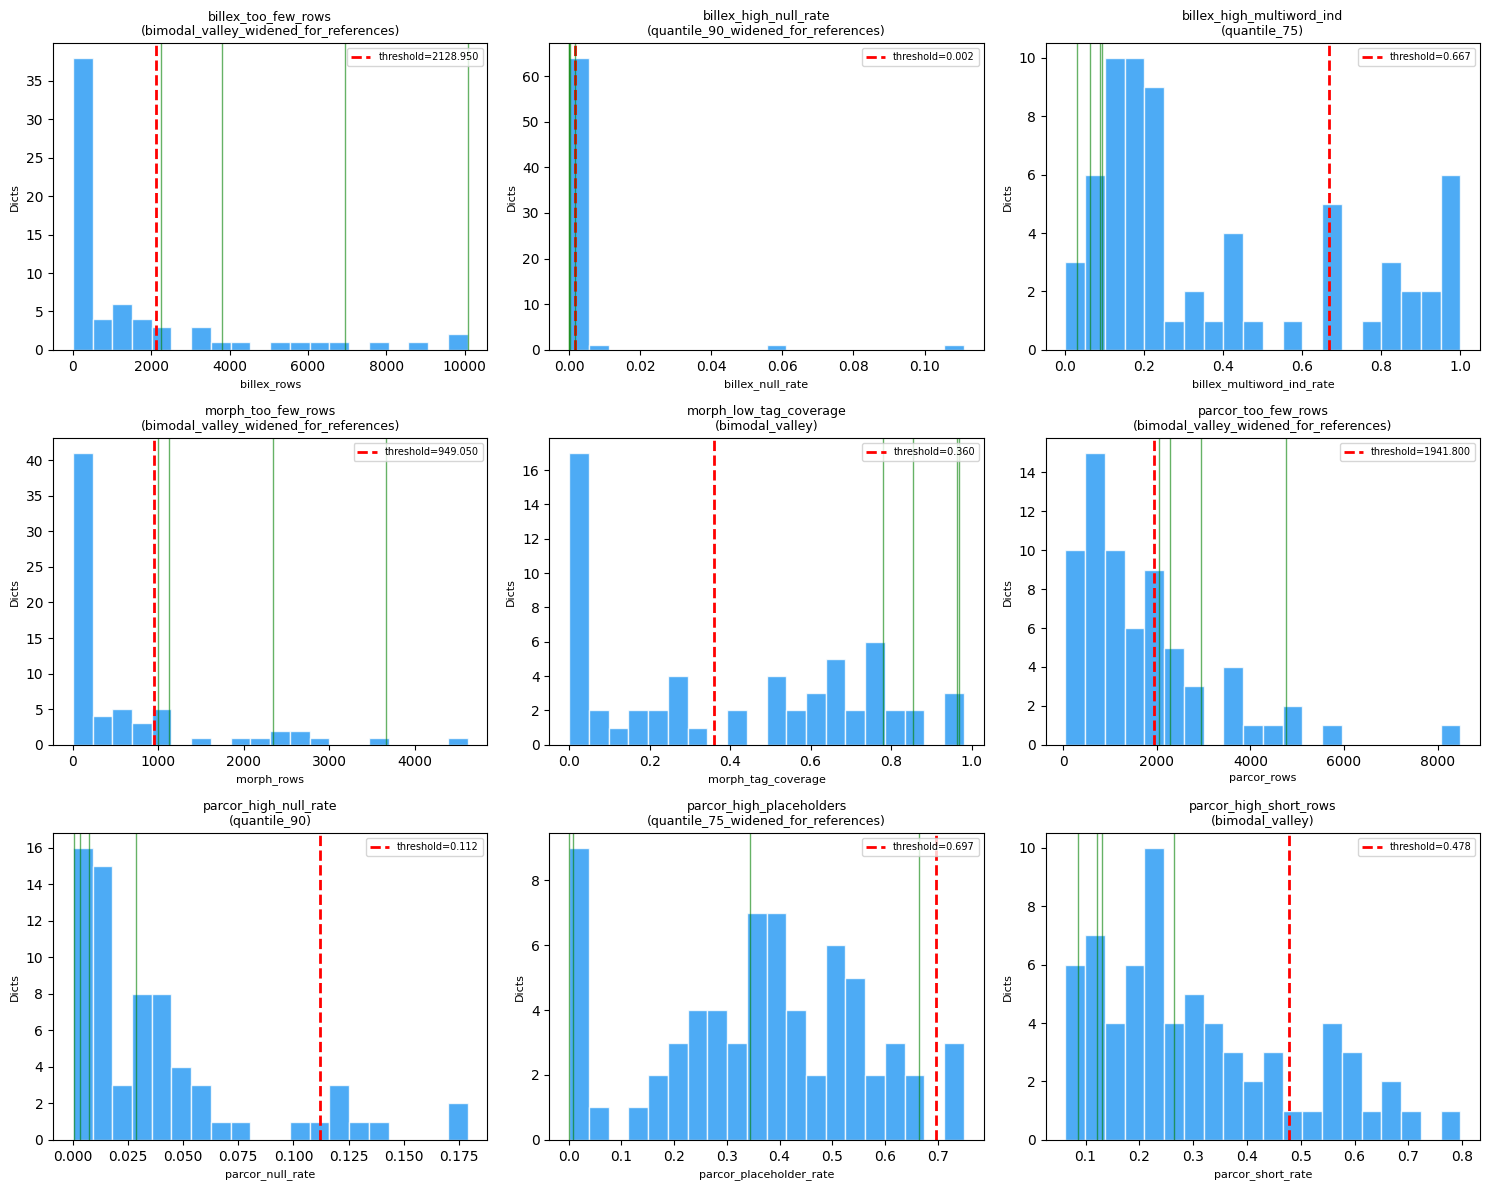


Saved to: ..\evaluation\calibration\_threshold_distributions.png


In [7]:
n_rules = len(thresholds_df)
n_cols = 3
n_rows = (n_rules + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_rules == 1 else axes

for ax, (_, row) in zip(axes, thresholds_df.iterrows()):
    col = row["metric_column"]
    values = metrics[col].dropna()
    ax.hist(values, bins=20, color="#2196f3", edgecolor="white", alpha=0.8)
    ax.axvline(row["threshold"], color="red", linestyle="--", linewidth=2,
               label=f"threshold={row['threshold']:.3f}")

    # Mark reference dicts
    ref_values = metrics[metrics["dict_id"].astype(str).isin(REFERENCE_GOOD_DICTS)][col].dropna()
    for v in ref_values:
        ax.axvline(v, color="green", linewidth=1, alpha=0.6)

    ax.set_title(f"{row['rule_name']}\n({row['method']})", fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel("Dicts", fontsize=8)
    ax.legend(fontsize=7, loc="upper right")

# Hide unused subplots
for ax in axes[n_rules:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(DST_DIR / "_threshold_distributions.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"\nSaved to: {DST_DIR / '_threshold_distributions.png'}")

## 8. Summary

The thresholds derived here are written to `_threshold_justifications.csv`
and will be consumed by `Distribution Sanity Checks v2.ipynb` in place of
the hardcoded thresholds from v1.

**Green lines in the plots above** mark where each of the 4 reference "good"
dictionaries fall. They should all be on the favorable side of the red
dashed threshold. If any green line crosses the red line, the safety check
in §4 widened the threshold.

Re-run this notebook whenever the underlying metrics change (e.g., after
adding new dictionaries or modifying the metric collectors).